# Introduction to Python course (BIO102.1)
* Postgraduate MSc Program in "Bioinformatics"
* (https://bioinfo-grad.gr/en/)
  
### Contact
- alexandros.pittis@gmail.com
- alexandros.pittis@imbb.forth.gr

# Part B - Data analysis, packages, plotting

# Environment - Tools

## Ubuntu installation in Windows
- Check Windows Subsystem for Linux (<a href="https://ubuntu.com/desktop/wsl">WSL</a>)

**Optional**: Consider a symbolic link of a data folder in WSL ~/Documents/

```bash
ln -s /mnt/c/myrepo ~/Documents/my_dir
```

## Ways to run python code
- Write code in python script and execute in **shell** (*python script_name.py*)
- Execute in **(i)python** command shell (*ipython: %run script_name.py*)
- **jupyter** notebook/lab
- VS code integrated terminal etc.
- ..

! Check relative path

Do note that there are multiple ways to create a virtualenv, such as:

- The venv module.
- The virtualenv package.
- Via package managers like conda.

We will use conda (minimum installation of Anaconda Distribution).

## Installing Miniconda (https://docs.anaconda.com/miniconda/install/)
**Linux instructions** Terminal or here..
- create a new directory named “miniconda3” in your home directory.
- download the Linux Miniconda installation script for your chosen chip architecture and save the script as -miniconda.sh in the miniconda3 directory.
- run the miniconda.sh installation script in silent mode using bash.
- remove the miniconda.sh installation script file after installation is complete.

```bash
mkdir -p ~/miniconda3
wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda3/miniconda.sh
bash ~/miniconda3/miniconda.sh -b -u -p ~/miniconda3
rm ~/miniconda3/miniconda.sh
```
- after installing, close and reopen your terminal application or refresh it by running the following command

```bash
source ~/miniconda3/bin/activate
```
- Then, initialize conda on all available shells

```bash
conda init --all
```


## Create conda environment - install jupyter

- we create the environment "python_intro", activate it, and install packages, and kernel

```bash
# conda create -n python_course python=3.11 notebook
conda create --name python_intro --channel=conda-forge python=3.11 jupyterlab nb_conda_kernels
conda activate python_intro
conda install -c bioconda hmmer #mafft fasttree datamash mmseqs2 astral-tree biopython
# pip install ipykernel
python -m ipykernel install --user --name python_intro --display-name "Python Intro"
```


* Download the notebook (project.ipynb), rename or copy (project_myname.ipynb) and run:

```bash
jupyter-lab project_myname.ipynb
```

- **Use one cell per code line/block, and look for function or method help (help(str.split) or str.split?).**

# Project - <a href="https://en.wikipedia.org/wiki/Codon_usage_bias">Codon usage bias</a>

There are 64 different codons (61 codons encoding for amino acids and 3 stop codons) but only 20 different translated amino acids. Most amino acids are coded by various codons, i.e, a few codons are synonyms and this aspect is known as the degeneracy of genetic code. It is thought that "optimal" codons -codons for which more tRNA genes exist- help to achieve faster translation rates, therefore "optimized" and highly expressed genes are expected to preferentially contain "optimal" codons.

![genetic code](https://microbenotes.com/wp-content/uploads/2018/08/Characteristic-of-Genetic-Code.jpg)

## Translation (mRNA 2 protein sequence)
- We will use NCBI Genomes <a href="https://www.ncbi.nlm.nih.gov/datasets/genome/">data</a>.
- You may also access it programmatically via <a href="https://www.ncbi.nlm.nih.gov/datasets/docs/v2/command-line-tools/download-and-install/">command-line tools</a> or <a href="https://biopython.org/docs/1.76/api/Bio.Entrez.html">Biopython</a>.

- Files can also be found in https://github.com/cgenomicslab/intro-to-Python-course/tree/main/2025/data

In [3]:
seq_dict = {}
with open("data/KT964724.1.fasta") as my_data:
    seq_key = 0
    seq_value = ""
    for line in my_data:
        line = line.strip()
        if line.startswith(">"):
            seq_key = line.split()[0]
            seq_value = ""
        else:
            seq_value += line
        if seq_key != 0 and seq_value !=0:
            seq_dict[seq_key] = seq_value
print(seq_dict)

{'>KT964724.1': 'ATTACTATATTTTAATTGAGTGCCTAGTGAGCAGCAATGGACTCCCGTATGGAAAGGGCAGAGTCTGTCTTTGCAGGCAGTATAAAGAGTAAACTCATTGCTGACTTAGTTTATGAGGACCAAACCTACAAGTTGTCAGGGGAAGGGTTTGGGAACCCCCAAGAGGGTCAGCATACGTTAGAGATGAGGTGTTTTGGTACGGAGGCATGCCCTCTTTCATGGTTTGTACTGGGTCCAGTGATACAGTACAGTTACAGAATGTTCACCCAGTATTCAGGTAACGGAATGTACGACTTCTTCAAGACCTCCTTCCCTGGTGGTCTTAGTACAGAGTCAGTGTGTACCTTCAATGATGGGGCTACTATCACTGGCAGTCATAATATCAGCTTTGTCAAGGACATCGTGGTCTGCAGATCTAAGCTGGAGTGCGCAGGGTTCAATGACGAGTCTCTGGCCCTGTCCCAGGAGCTGTCCCAAGTCAAGCCTTGTTACGAGATAATAGATGGATCCGGAGTAGACGCTGTTTCCAGCTCTGTCAAACTCGAGTGGGACTTGTCAGACGGGGATAAGTACAGTGCCCAGGTAGAGTCAGTGATCAGGAGTAAGACCAACTTTGCACCACAGAGACACTTTATAGCTCATCACAGCAAGGTGATTGAAAAGTCGCAGAACAATCTGCACTTTTCCCAGCGTGATAAGTCCAGAGCAAACGTCATCAACTTCTACCTGCATAAAGAACAACACAAACGATAGGTCACGTTTAATGAGCAAGTTCTCGCAGTCTGTTTAGCACTCCGGGACTCTGTCTACCGTGGGAACTGAGAGGTGTCACGGGGAAGATGTCTGTTTGTATTCGGTAGTTAATTTGAACTTGAAGGGAGTTTGTATGGAGTTGCTTGTTGAATGGGATAAAGCTTTTGAAATGCTTGAGAAGCTTAGGAAGCGGAAGAGTTAAGAGGGGATTTTGAAAAAGGAATGCTTAA

- Find the overall length of the sequence?

In [4]:
length = len(seq_dict['>KT964724.1'])
print(f"The length of the sequence is: {length}.")

The length of the sequence is: 999.


- Get the reverse of the sequence using **indexing with negative step** (sequence[Start : End : Step], see also [here](https://www.geeksforgeeks.org/slicing-with-negative-numbers-in-python/) for slicing)

In [5]:
seq = seq_dict['>KT964724.1']
reverse_seq = seq[::-1]
print(reverse_seq)

GCAGTTTGTTTTATTAAATTCGTAAGGAAAAAGTTTTAGGGGAGAATTGAGAAGGCGAAGGATTCGAAGAGTTCGTAAAGTTTTCGAAATAGGGTAAGTTGTTCGTTGAGGTATGTTTGAGGGAAGTTCAAGTTTAATTGATGGCTTATGTTTGTCTGTAGAAGGGGCACTGTGGAGAGTCAAGGGTGCCATCTGTCTCAGGGCCTCACGATTTGTCTGACGCTCTTGAACGAGTAATTTGCACTGGATAGCAAACACAACAAGAAATACGTCCATCTTCAACTACTGCAAACGAGACCTGAATAGTGCGACCCTTTTCACGTCTAACAAGACGCTGAAAAGTTAGTGGAACGACACTACTCGATATTTCACAGAGACACCACGTTTCAACCAGAATGAGGACTAGTGACTGAGATGGACCCGTGACATGAATAGGGGCAGACTGTTCAGGGTGAGCTCAAACTGTCTCGACCTTTGTCGCAGATGAGGCCTAGGTAGATAATAGAGCATTGTTCCGAACTGAACCCTGTCGAGGACCCTGTCCCGGTCTCTGAGCAGTAACTTGGGACGCGTGAGGTCGAATCTAGACGTCTGGTGCTACAGGAACTGTTTCGACTATAATACTGACGGTCACTATCATCGGGGTAGTAACTTCCATGTGTGACTGAGACATGATTCTGGTGGTCCCTTCCTCCAGAACTTCTTCAGCATGTAAGGCAATGGACTTATGACCCACTTGTAAGACATTGACATGACATAGTGACCTGGGTCATGTTTGGTACTTTCTCCCGTACGGAGGCATGGTTTTGTGGAGTAGAGATTGCATACGACTGGGAGAACCCCCAAGGGTTTGGGAAGGGGACTGTTGAACATCCAAACCAGGAGTATTTGATTCAGTCGTTACTCAAATGAGAAATATGACGGACGTTTCTGTCTGAGACGGGAAAGGTATGCCCTCAGGTAACGACGAGTGATCCGTGAGTTAATTTTATATCATTA


- How many start codons (ATG) can be found in the three 5′→3′ reading frames? (**str.count?** for help)

In [6]:
sequence = seq_dict[">KT964724.1"]
atg_count = sequence.count('ATG')
print(f"The number of ATG codon in the sequence is {atg_count}")

The number of ATG codon in the sequence is 18


- If the sequence starts with a start codon keep it, else find the first ATG (if first three letters == "ATG" else find it) and remove trailing sequence upstream. (**str.find?** for help)

In [7]:
sequence = seq_dict[">KT964724.1"]
base = sequence.find("ATG")
print(f"The first ATG is in position {base}")
gene = sequence[36:]
print(gene)

The first ATG is in position 36
ATGGACTCCCGTATGGAAAGGGCAGAGTCTGTCTTTGCAGGCAGTATAAAGAGTAAACTCATTGCTGACTTAGTTTATGAGGACCAAACCTACAAGTTGTCAGGGGAAGGGTTTGGGAACCCCCAAGAGGGTCAGCATACGTTAGAGATGAGGTGTTTTGGTACGGAGGCATGCCCTCTTTCATGGTTTGTACTGGGTCCAGTGATACAGTACAGTTACAGAATGTTCACCCAGTATTCAGGTAACGGAATGTACGACTTCTTCAAGACCTCCTTCCCTGGTGGTCTTAGTACAGAGTCAGTGTGTACCTTCAATGATGGGGCTACTATCACTGGCAGTCATAATATCAGCTTTGTCAAGGACATCGTGGTCTGCAGATCTAAGCTGGAGTGCGCAGGGTTCAATGACGAGTCTCTGGCCCTGTCCCAGGAGCTGTCCCAAGTCAAGCCTTGTTACGAGATAATAGATGGATCCGGAGTAGACGCTGTTTCCAGCTCTGTCAAACTCGAGTGGGACTTGTCAGACGGGGATAAGTACAGTGCCCAGGTAGAGTCAGTGATCAGGAGTAAGACCAACTTTGCACCACAGAGACACTTTATAGCTCATCACAGCAAGGTGATTGAAAAGTCGCAGAACAATCTGCACTTTTCCCAGCGTGATAAGTCCAGAGCAAACGTCATCAACTTCTACCTGCATAAAGAACAACACAAACGATAGGTCACGTTTAATGAGCAAGTTCTCGCAGTCTGTTTAGCACTCCGGGACTCTGTCTACCGTGGGAACTGAGAGGTGTCACGGGGAAGATGTCTGTTTGTATTCGGTAGTTAATTTGAACTTGAAGGGAGTTTGTATGGAGTTGCTTGTTGAATGGGATAAAGCTTTTGAAATGCTTGAGAAGCTTAGGAAGCGGAAGAGTTAAGAGGGGATTTTGAAAAAGGAATGCTTAAATTATTTTGTTTGACG


- Find the **first** in-frame stop codon (TAA, TAG, TGA) (**increment counter by 3 in a while loop**)

In [8]:
final_gene = ""
for b in range(0, len(gene), 3):
    base = gene[b:b+3]
    if base == "TAA" or base == "TAG" or base == "TGA":
        break
    else:
        final_gene += base
print(final_gene)

ATGGACTCCCGTATGGAAAGGGCAGAGTCTGTCTTTGCAGGCAGTATAAAGAGTAAACTCATTGCTGACTTAGTTTATGAGGACCAAACCTACAAGTTGTCAGGGGAAGGGTTTGGGAACCCCCAAGAGGGTCAGCATACGTTAGAGATGAGGTGTTTTGGTACGGAGGCATGCCCTCTTTCATGGTTTGTACTGGGTCCAGTGATACAGTACAGTTACAGAATGTTCACCCAGTATTCAGGTAACGGAATGTACGACTTCTTCAAGACCTCCTTCCCTGGTGGTCTTAGTACAGAGTCAGTGTGTACCTTCAATGATGGGGCTACTATCACTGGCAGTCATAATATCAGCTTTGTCAAGGACATCGTGGTCTGCAGATCTAAGCTGGAGTGCGCAGGGTTCAATGACGAGTCTCTGGCCCTGTCCCAGGAGCTGTCCCAAGTCAAGCCTTGTTACGAGATAATAGATGGATCCGGAGTAGACGCTGTTTCCAGCTCTGTCAAACTCGAGTGGGACTTGTCAGACGGGGATAAGTACAGTGCCCAGGTAGAGTCAGTGATCAGGAGTAAGACCAACTTTGCACCACAGAGACACTTTATAGCTCATCACAGCAAGGTGATTGAAAAGTCGCAGAACAATCTGCACTTTTCCCAGCGTGATAAGTCCAGAGCAAACGTCATCAACTTCTACCTGCATAAAGAACAACACAAACGA


- Get the **coding sequence** from start codon to last (before last codon)

- Write a **function** that takes mRNA (cds, nucleotides) as input and returns the amino acid (aa) sequence using the standard genetic code (below).

```python
codon2aa = {
        'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',
        'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
        'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
        'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',                 
        'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
        'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
        'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
        'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
        'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V',
        'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
        'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
        'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
        'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
        'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
        'TAC':'Y', 'TAT':'Y', 'TAA':'*', 'TAG':'*',
        'TGC':'C', 'TGT':'C', 'TGA':'*', 'TGG':'W'
    }
```    

In [9]:
def translate(nucleotides):
    codon2aa = {
        'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',
        'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
        'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
        'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',                 
        'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
        'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
        'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
        'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
        'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V',
        'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
        'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
        'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
        'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
        'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
        'TAC':'Y', 'TAT':'Y', 'TAA':'*', 'TAG':'*',
        'TGC':'C', 'TGT':'C', 'TGA':'*', 'TGG':'W'
    }
    protein_seq = ""
    for i in range (0, len(nucleotides), 3):
        tripleta = nucleotides[i:i+3]
        if len(tripleta) != 3 or tripleta in ['TAA','TGA','TAG']:
            continue
        else:
            amino_acid = codon2aa.get(tripleta,'')
            protein_seq += amino_acid
    return(protein_seq)
translate(final_gene)            

'MDSRMERAESVFAGSIKSKLIADLVYEDQTYKLSGEGFGNPQEGQHTLEMRCFGTEACPLSWFVLGPVIQYSYRMFTQYSGNGMYDFFKTSFPGGLSTESVCTFNDGATITGSHNISFVKDIVVCRSKLECAGFNDESLALSQELSQVKPCYEIIDGSGVDAVSSSVKLEWDLSDGDKYSAQVESVIRSKTNFAPQRHFIAHHSKVIEKSQNNLHFSQRDKSRANVINFYLHKEQHKR'

## Codon frequencies

- What is the GC content of the gene? Write a **function** that returns it and print "Gene's GC content: X%" using string formatting (2 decimals).

In [11]:
total_seq = seq_dict[">KT964724.1"]
bases = len(total_seq)
G_number = total_seq.count('G')
C_number = total_seq.count('C')
GC_content = ((G_number + C_number)/bases)*100
print("Gene's GC content: %.2f%%" %GC_content)

Gene's GC content: 45.65%


- Count the number of total and unique codons in the sequence (list vs set). see **range** function (**range? for help**).

In [13]:
def find_unique_codons():
    list_of_codons = []
    list_of_unique_codons = []
    for i in range (0, len(final_gene), 3):
        codons = final_gene[i:i+3]
        if codons not in list_of_codons:
            list_of_unique_codons.append(codons)
        list_of_codons.append(codons)
    print(f"The total numbers of codons in the sequence is {len(list_of_codons)}\
 and {len(list_of_unique_codons)} of them are unique\
 and length of sequence is {len(final_gene)}")
find_unique_codons()

The total numbers of codons in the sequence is 238 and 56 of them are unique and length of sequence is 714


- Create a codon counter, dictionary with codons as keys, their count as value (check also dict.setdefault method).

In [14]:
def codon_counter():
    codon_count_dict = {}
    list_of_codons = []
    for i in range (0, len(final_gene), 3):
        codons = final_gene[i:i+3]
        list_of_codons.append(codons)
    for i in list_of_codons:
        codon_count_dict.setdefault(i,0)
        codon_count_dict[i] +=1
    return(codon_count_dict)
codon_counter()

{'ATG': 5,
 'GAC': 9,
 'TCC': 8,
 'CGT': 2,
 'GAA': 4,
 'AGG': 3,
 'GCA': 6,
 'GAG': 12,
 'TCT': 4,
 'GTC': 6,
 'TTT': 8,
 'GGC': 2,
 'AGT': 7,
 'ATA': 5,
 'AAG': 11,
 'AAA': 4,
 'CTC': 2,
 'ATT': 2,
 'GCT': 4,
 'TTA': 2,
 'GTT': 2,
 'TAT': 2,
 'CAA': 4,
 'ACC': 5,
 'TAC': 7,
 'TTG': 2,
 'TCA': 6,
 'GGG': 6,
 'AAC': 6,
 'CCC': 1,
 'GGT': 6,
 'CAG': 8,
 'CAT': 4,
 'ACG': 2,
 'TGT': 3,
 'TGC': 3,
 'CCT': 3,
 'CTT': 2,
 'TGG': 2,
 'GTA': 3,
 'CTG': 7,
 'CCA': 2,
 'GTG': 5,
 'AGA': 4,
 'TTC': 7,
 'GGA': 3,
 'ACA': 1,
 'AAT': 4,
 'GAT': 4,
 'ACT': 2,
 'ATC': 5,
 'AGC': 3,
 'GCC': 2,
 'CAC': 4,
 'TCG': 1,
 'CGA': 1}

- Do the same using Python’s Counter (import from collections).

In [15]:
from collections import Counter
codon_count = Counter()
for i in range (0, len(final_gene), 3):
    codons = final_gene[i:i+3]
    codon_count[codons] += 1
for codon, count in codon_count.items():
    print(f"{codon}:{count}")

ATG:5
GAC:9
TCC:8
CGT:2
GAA:4
AGG:3
GCA:6
GAG:12
TCT:4
GTC:6
TTT:8
GGC:2
AGT:7
ATA:5
AAG:11
AAA:4
CTC:2
ATT:2
GCT:4
TTA:2
GTT:2
TAT:2
CAA:4
ACC:5
TAC:7
TTG:2
TCA:6
GGG:6
AAC:6
CCC:1
GGT:6
CAG:8
CAT:4
ACG:2
TGT:3
TGC:3
CCT:3
CTT:2
TGG:2
GTA:3
CTG:7
CCA:2
GTG:5
AGA:4
TTC:7
GGA:3
ACA:1
AAT:4
GAT:4
ACT:2
ATC:5
AGC:3
GCC:2
CAC:4
TCG:1
CGA:1


- Estimate the **frequencies** of **codons** and of **aa categories** below (A, B, C, D) - Ratio over total number of codons.
    - Use list comprehension and Python’s Counter (import from collections).
    - ```python
      cat2aa = {'A':['R','H','K', 'D', 'E']} etc.
      ```

![title](https://cdn.technologynetworks.com/tn/images/body/aminoacids-pic3revised1574260662291.png)

In [16]:
from collections import Counter
cat2aa = {'A' : ['R','H','K','D','E'],
          'B' : ['S','T','N','Q'],
          'C' : ['C','G','P'],
          'D' : ['A','V','I','L','M','F','Y','W']
         }
amino_acidA = 0
amino_acidB = 0
amino_acidC = 0
amino_acidD = 0
percentance_of_A = None
percentance_of_B = None
percentance_of_C = None
percentance_of_D = None
protein_seq = translate(final_gene)
for i in protein_seq:
    if i in cat2aa['A']:
        amino_acidA += 1
    if i in cat2aa['B']:
        amino_acidB += 1
    if i in cat2aa['C']:
        amino_acidC += 1
    if i in cat2aa['D']:
        amino_acidD += 1
percentance_of_A = (amino_acidA / len(protein_seq))*100
percentance_of_B = (amino_acidB / len(protein_seq))*100
percentance_of_C = (amino_acidC / len(protein_seq))*100
percentance_of_D = (amino_acidD / len(protein_seq))*100
print(f"Percentance of amino acid in category A is {percentance_of_A}, \
percentance of amino acid in category B is {percentance_of_B}, \
percentance of amino acid in category C is {percentance_of_C}, \
and percentance of amino acid in category D is {percentance_of_D}.")

codon_dict = codon_counter()
total_codons = sum(codon_dict.values())
for key in codon_dict:
    codon_dict[key] = ((codon_dict[key]/total_codons))
print(codon_dict)

Percentance of amino acid in category A is 26.05042016806723, percentance of amino acid in category B is 25.630252100840334, percentance of amino acid in category C is 12.184873949579831, and percentance of amino acid in category D is 36.134453781512605.
{'ATG': 0.02100840336134454, 'GAC': 0.037815126050420166, 'TCC': 0.03361344537815126, 'CGT': 0.008403361344537815, 'GAA': 0.01680672268907563, 'AGG': 0.012605042016806723, 'GCA': 0.025210084033613446, 'GAG': 0.05042016806722689, 'TCT': 0.01680672268907563, 'GTC': 0.025210084033613446, 'TTT': 0.03361344537815126, 'GGC': 0.008403361344537815, 'AGT': 0.029411764705882353, 'ATA': 0.02100840336134454, 'AAG': 0.046218487394957986, 'AAA': 0.01680672268907563, 'CTC': 0.008403361344537815, 'ATT': 0.008403361344537815, 'GCT': 0.01680672268907563, 'TTA': 0.008403361344537815, 'GTT': 0.008403361344537815, 'TAT': 0.008403361344537815, 'CAA': 0.01680672268907563, 'ACC': 0.02100840336134454, 'TAC': 0.029411764705882353, 'TTG': 0.008403361344537815, '

## Genome scale

- **Download** and **parse** the Genomic coding sequences (cds) for the Reference African savanna elephant (*Loxodonta africana*) genome from [NCBI](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_030014295.1/)
    - We want the CDS (cds_from_genomic.fna.gz) from the [ftp site](https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/030/014/295/GCF_030014295.1_mLoxAfr1.hap2/).
    - You may also find the file in [data/GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.fna.gz](https://github.com/cgenomicslab/intro-to-Python-course/raw/refs/heads/main/2025/data/GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.fna.gz)
    - Modify the *load_fasta* function accordingly to keep as dictionary keys the unique IDs of each entry (e.g. NC_087342.1_cds_XP_064145200.1_6)
    - **Optional**: There are multiple transcripts/isoforms per gene. To avoid redundancy in the data we may keep only the longest transcript/isoform per gene. (**Very important in real life!**)

```bash
wget -O data/GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.fna.gz -q "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/030/014/295/GCF_030014295.1_mLoxAfr1.hap2/GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.fna.gz"
```


**Note** that the downloaded file is compressed (*gz). You may decompress it first using the gunzip command, or better import and use the Python *gzip module* in your new load_fasta function (remember to convert binary to text with .decode('utf-8')).

Example:
```python
import gzip
with gzip.open('mypath/file.txt.gz', 'rb') as f:
   for line in f:
       # read line by line
       line = line.strip().decode('utf-8')
       print(line)
       ...
```

See also gzip.open?

In [17]:
import json
with open("./data/GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.fna") as my_file:
    elephant_genome_dict = {}
    header = None
    sequence = ''
    for line in my_file:
        line = line.strip()
        if line.startswith(">"):
            if header:
                elephant_genome_dict[header] = sequence
            header = line.split()[0]
            sequence = ''
        else:
            sequence += line.replace("\n",'')
    if header != None and sequence != None:
        elephant_genome_dict[header] = sequence
    print()
ten_first_keys = list(elephant_genome_dict.keys())[:10]
output_file= "elephant_genome"
print(ten_first_keys)
with open(output_file, 'w') as file: 
    json.dump(elephant_genome_dict, file, indent = len(elephant_genome_dict))
    


['>lcl|NC_087342.1_cds_XP_003413047.1_1', '>lcl|NC_087342.1_cds_XP_023407606.1_2', '>lcl|NC_087342.1_cds_XP_064143503.1_3', '>lcl|NC_087342.1_cds_XP_023407607.1_4', '>lcl|NC_087342.1_cds_XP_064145410.1_5', '>lcl|NC_087342.1_cds_XP_064145200.1_6', '>lcl|NC_087342.1_cds_XP_003413045.1_7', '>lcl|NC_087342.1_cds_XP_010591275.2_8', '>lcl|NC_087342.1_cds_XP_023407605.1_9', '>lcl|NC_087342.1_cds_XP_010591268.1_10']


- **Check** if all CDS start with a start codon (ATG). How many transcripts do NOT start from ATG.

According to the [README file](https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/030/014/295/GCF_030014295.1_mLoxAfr1.hap2/README.txt):
  "For CDS features that begin in frame 2 or 3, the first 1 or 2 bp of sequence
are trimmed from the CDS FASTA so that it always begins with the first complete
codon. The location and frame qualifiers are left unaltered; consequently, the 
length of the ranges in the location string may be 1-2 bp longer than the FASTA 
sequence." 

In [18]:
count = 0
list_of_keys = []
for key,value in elephant_genome_dict.items():
    if value.startswith('ATG'):
        continue
    else:
        count += 1
        list_of_keys.append(key)
print(f"{count} CDS don't start with ATG")
#print(list_of_keys)

83 CDS don't start with ATG


- Estimate the overall codon frequencies of the elephant genome

In [19]:
codon_frequency = {}
total_lenght = sum(len(value) for value in elephant_genome_dict.values())/3
for key, value in elephant_genome_dict.items():
    for i in range (0,len(value),3):
        codon = value[i:i+3]
        if codon in codon_frequency:
            codon_frequency[codon] += 1     
        else:
            codon_frequency[codon] = 1
for key, value in codon_frequency.items():
    codon_frequency[key] = value / total_lenght
print(f"The whole elephant genome include {total_lenght} codons")
#print(codon_frequency)
sort_codon_frequency =\
{key: value for key,value in sorted(codon_frequency.items(),\
key = lambda item:item[1], reverse = True)}
print(sort_codon_frequency)

The whole elephant genome include 37747556.0 codons
{'GAG': 0.03973634743399016, 'CAG': 0.03642590794487463, 'CTG': 0.03627824275563695, 'GAA': 0.03249738870511246, 'AAG': 0.0319440813598634, 'AAA': 0.027077673585013028, 'GCC': 0.026008544765123338, 'GTG': 0.025752846091545635, 'GAC': 0.02466827256312965, 'GAT': 0.023047664330903966, 'ATG': 0.021542454298233243, 'AGC': 0.01975388817225677, 'GGC': 0.019656212974424093, 'CCC': 0.01892594052976569, 'CCT': 0.018917701585766243, 'GCT': 0.01890480008824942, 'AAC': 0.018791123854482127, 'ATC': 0.01877451350757649, 'CCA': 0.018267381337218228, 'CTC': 0.01813439259484773, 'TTC': 0.018009695780039376, 'ACC': 0.017792224746947857, 'AAT': 0.017760196183297272, 'TTT': 0.017484946575084225, 'TCC': 0.01741447843669667, 'TCT': 0.016732235591623467, 'GCA': 0.01664685258033659, 'GGA': 0.016378623294180952, 'ATT': 0.016295518576090066, 'ACA': 0.015877451774626152, 'GGG': 0.015234761159106566, 'CAC': 0.015196268600806898, 'AGT': 0.014371817873453848, 'CTT

## Plotting - data visualization

- Plot the codon frequency counts, and normalized codon frequency per aa in a barplot.

We need to install different libraries matplotlib, pandas, (seaborn, plotly, altair). See also [here](https://medium.com/weekly-python/data-visualization-in-python-matplotlib-seaborn-and-plotly-f1d6192f7d)

[Matplotlib](https://matplotlib.org/)

In [21]:
import matplotlib.pyplot as plt
x_axes = list(codon_frequency.keys())
y_axes = [codon_frequency[codon] for codon in x_axes]
print(x_axes, y_axes)

['ATG', 'CTG', 'GCA', 'GTT', 'AGG', 'AAA', 'GCG', 'CTC', 'GGG', 'ACT', 'TGC', 'TCC', 'CCG', 'AAC', 'CCC', 'AGC', 'ACA', 'AAG', 'TCA', 'TCG', 'GAG', 'GTC', 'AAT', 'GCC', 'GAC', 'TGG', 'CTT', 'TCT', 'CAC', 'ATA', 'CCA', 'GGC', 'TTC', 'TAC', 'GTA', 'GAT', 'GAA', 'GTG', 'CCT', 'CAA', 'ACC', 'GCT', 'ATC', 'CGC', 'TTG', 'ACG', 'CAG', 'TTT', 'CGA', 'CGT', 'CAT', 'ATT', 'TAT', 'AGA', 'GGA', 'AGT', 'TGT', 'CTA', 'CGG', 'GGT', 'TGA', 'TTA', 'TAG', 'TAA'] [0.021542454298233243, 0.03627824275563695, 0.01664685258033659, 0.01174269401706431, 0.012002816818127244, 0.027077673585013028, 0.006271240447990858, 0.01813439259484773, 0.015234761159106566, 0.014133577283784943, 0.010789016380292277, 0.01741447843669667, 0.0064334496251889795, 0.018791123854482127, 0.01892594052976569, 0.01975388817225677, 0.015877451774626152, 0.0319440813598634, 0.014033411858505488, 0.004397211835383462, 0.03973634743399016, 0.013737631119747197, 0.017760196183297272, 0.026008544765123338, 0.02466827256312965, 0.01132772

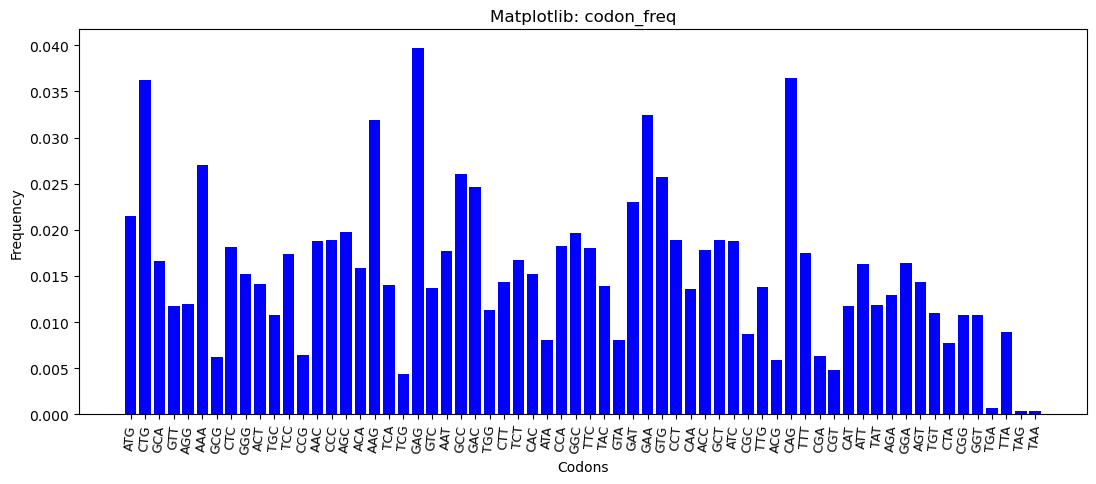

In [22]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [13, 5]

plt.bar(x_axes, y_axes, color='blue')
plt.xticks(rotation=85, fontsize=9)
plt.xlabel("Codons")
plt.ylabel("Frequency")
plt.title("Matplotlib: codon_freq")
plt.show()

[Seaborn](https://seaborn.pydata.org/)

In [23]:
import pandas as pd
df = pd.DataFrame({'Codons':x_axes,'Frequency':y_axes})

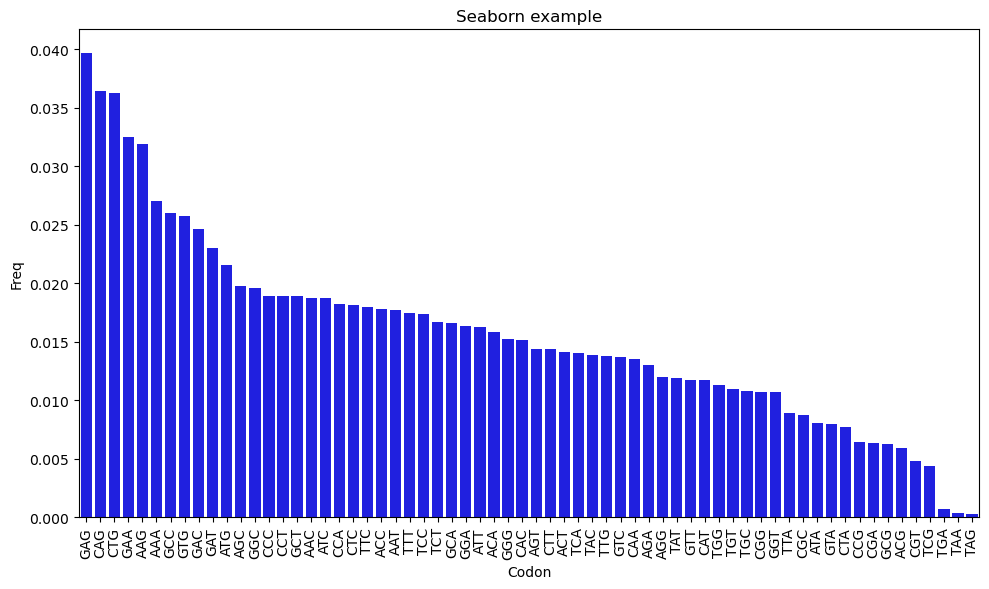

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sorted_codon_frequency = {key: value for key, value in sorted(codon_frequency.items(), key=lambda item: item[1], reverse=True)}
codon_df = pd.DataFrame(list(sorted_codon_frequency.items()), columns=['Codon', 'Freq'])
plt.figure(figsize=(10, 6))

sns.barplot(
    data=codon_df,     
    x='Codon',    
    y='Freq',         
    orient='v',     
    color='blue'
).set_title("Seaborn example")
plt.xticks(rotation=90)
plt.tight_layout()


[Plotly](https://plotly.com/python/)

In [25]:
import plotly.express as px

fig = px.bar(codon_df, x="Codon", y="Freq", color="Freq", title="Plotly example")
fig.show()

[Altair](https://altair-viz.github.io/)

In [26]:
import altair as alt
import pandas as pd 

codon_df = pd.DataFrame(list(codon_frequency.items()), columns=['Codon', 'Frequency'])
chart = alt.Chart(codon_df).mark_bar().encode(
    x=alt.X('Codon:N', title='Codon'),
    y=alt.Y('Frequency:Q', title='Frequency'),
).properties(
    title= 'Codon Frequency in Elephant Genome'
)
chart

alt.Chart(...)

## Optimal codons

- We screened the African savanna elephant genome for tRNA gene copies using the standalone version of the [tRNAscan-SE 2.0](https://lowelab.ucsc.edu/tRNAscan-SE/) tool, to find the optimal codons (highest number of tRNA genes for a given amino acid).

```python
aa2optimal = {'R': 'AGA',
              'S': 'AGC',
              'G': 'GGA',
              'E': 'GAA',
              'T': 'ACC',
              'A': 'GCA',
              'W': 'TGG',
              'P': 'CCA',
              'L': 'CTG',
              'K': 'AAA',
              'I': 'ATT',
              'M': 'ATG',
              'V': 'GTA',
              'Y': 'TAC',
              'H': 'CAC',
              'F': 'TTC',
              'Q': 'CAG',
              'D': 'GAC',
              'N': 'AAC',
              'C': 'TGC'}
```

- **Optional:** Instead of copying the dictionary, parse the output of the tRNAscan-SE program ([found in data/GCF_030014295.1_mLoxAfr1.hap2_genomic.tRNAscan.out](https://raw.githubusercontent.com/cgenomicslab/intro-to-Python-course/refs/heads/main/2025/data/GCF_030014295.1_mLoxAfr1.hap2_genomic.tRNAscan.out)), plot the ratios of the different codons in a stacked barplot, and find the optimal codons (per aa) yourselves.
    - Skip all lines with the Note "pseudo".
    - The prediction returns anticodons. The codon is the reverse complement of the anticodon (e.g. for Met CAT->ATG).
    - Convert iMet (initiator methionine) to Met.
    - Consider using BioPython to convert 3 letters to 1 letter code (*from Bio.Data.IUPACData import protein_letters_3to1*).

- Compute the ratio of optimal codons in a given gene (ratio of optimal codons over all codons).

In [31]:
aa2optimal = {'R': 'AGA',
              'S': 'AGC',
              'G': 'GGA',
              'E': 'GAA',
              'T': 'ACC',
              'A': 'GCA',
              'W': 'TGG',
              'P': 'CCA',
              'L': 'CTG',
              'K': 'AAA',
              'I': 'ATT',
              'M': 'ATG',
              'V': 'GTA',
              'Y': 'TAC',
              'H': 'CAC',
              'F': 'TTC',
              'Q': 'CAG',
              'D': 'GAC',
              'N': 'AAC',
              'C': 'TGC'}

def ratio_of_optimal_codons(gene):
    
    codon_list = []
    
    for i in range(0, len(gene), 3):
        codon = gene[i:i+3]
        codon_list.append(codon)
        
    total_codons = len(codon_list)
    optimal_codons = 0
    
    for codon in codon_list:
            if codon in aa2optimal.values():
                optimal_codons +=1                            
    return optimal_codons/total_codons
elephant_seq= ''.join(elephant_genome_dict.values())
ratio_of_optimal_codons(elephant_seq)

0.3926451026392278

- Write a function that takes as input a dictionary with seqid as keys, sequence (cds) as values, and a list of gene seqids, and returns the median optimal codon usage across all genes.
    - Consider as optimal codon usage the ratio of optimal codons across all codons

In [32]:
import statistics

def median_optimal_codon_usage(cds_dict, gene_seqids):

    optimal_ratios = []

    for seqid in gene_seqids:
        if seqid in cds_dict:
            gene_sequence = cds_dict[seqid]
            ratio = ratio_of_optimal_codons(gene_sequence)
            optimal_ratios.append(ratio)
    
    
    return statistics.median(optimal_ratios)

cds_dict = elephant_genome_dict

gene_seqids = list(elephant_genome_dict.keys())

median_usage = median_optimal_codon_usage(cds_dict, gene_seqids)
print(f"Median Optimal Codon Usage: {median_usage:.2f}%")


Median Optimal Codon Usage: 0.39%


## Permutation test

- Randomly sample 100 genes, repeat it 1000 times each time computing and storing the median optimal codon ratio (**random.choices?**). Plot in a histogram the distribution of the median values of the random permutations.
    - Add a vertical line where the median value of the first 100 seqids fall across the distribution.

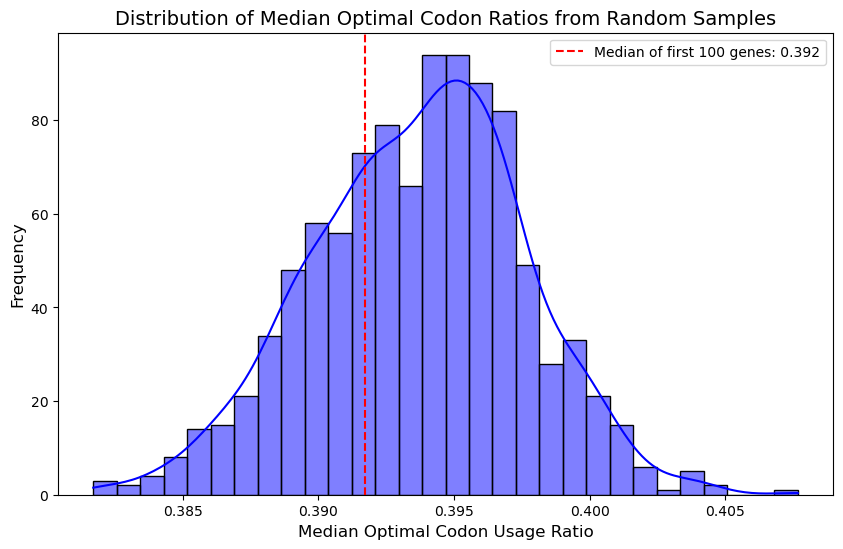

In [33]:
import random
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

def random_sampling_median(cds_dict, n_samples=100, n_iterations=1000):
    all_medians = []
    
    for _ in range(n_iterations):
        sampled_genes = random.choices(list(cds_dict.values()), k=n_samples)
        optimal_ratios = [ratio_of_optimal_codons(gene) for gene in sampled_genes]
        median_ratio = statistics.median(optimal_ratios)
        all_medians.append(median_ratio)
    
    return all_medians

def plot_histogram_with_median_line(cds_dict, gene_seqids):
    first_100_genes = [cds_dict[seqid] for seqid in gene_seqids[:100]]
    first_100_ratios = [ratio_of_optimal_codons(gene) for gene in first_100_genes]
    first_100_median = statistics.median(first_100_ratios)
    
    all_medians = random_sampling_median(cds_dict, n_samples=100, n_iterations=1000)
    
    plt.figure(figsize=(10, 6))
    sns.histplot(all_medians, kde=True, bins=30, color='blue')
    
    plt.axvline(x=first_100_median, color='red', linestyle='--', label=f"Median of first 100 genes: {first_100_median:.3f}")
    
    plt.title('Distribution of Median Optimal Codon Ratios from Random Samples', fontsize=14)
    plt.xlabel('Median Optimal Codon Usage Ratio', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    
    plt.show()

key_list = list(elephant_genome_dict.keys())

plot_histogram_with_median_line(elephant_genome_dict, key_list)


## Olfactory Receptors codon usage

The Olfactory Receptor (OR) genes superfamily forms the largest gene family in the vertebrate genomes. ORs belong to the G-protein-coupled receptor family and play a critical role in recognizing thousands of odorant molecules in the olfactory sensory system.

The family is an extreme example of gene family expansion (via gene duplication) and losses, which probably reflect species-specific adaptations, and the elephant genome has been shown to encode the largest number of ORs.

![OR barplot](https://www.u-tokyo.ac.jp/content/400022567.jpg)

- We want to **test if OR genes have low rates of optimal codon usage** compared to the random expectation, due to their dynamic mode of evolution (null hypothesis being that all genes/samples come from the same optimal codon usage distribution).
- We use the Pfam Profile HMM for Olfactory Receptors (ORs) ([PF13853](https://www.ebi.ac.uk/interpro/entry/pfam/PF13853/)) and the [HMMER tool](http://hmmer.org/) to screen the elephant genome for OR sequences.
    - We first need to translate cds into peptide sequences, to be able to search for PF13853 domain-containing sequences, using the "gathering threshold" (--cut_ga).
    - ```bash
      hmmsearch -o /dev/null --cpu 8 --tblout data/PF13853.vs.GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.translated.tblout --cut_ga data/PF13853.hmm data/GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.translated.fasta
      ```
    - The tab-delimited output can be found in [*data/PF13853.vs.GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.translated.tblout*](https://raw.githubusercontent.com/cgenomicslab/intro-to-Python-course/refs/heads/main/2025/data/PF13853.vs.GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.translated.tblout)
    - To "wget" use url "https://raw.githubusercontent.com/cgenomicslab/intro-to-Python-course/refs/heads/main/2025/data/PF13853.vs.GCF_030014295.1_mLoxAfr1.hap2_cds_from_genomic.translated.tblout"
    - Consider as ORs all cds found in hmmsearch's ouput (peptides containing a Olfactory receptor (PF13853) domain for the given threshold)

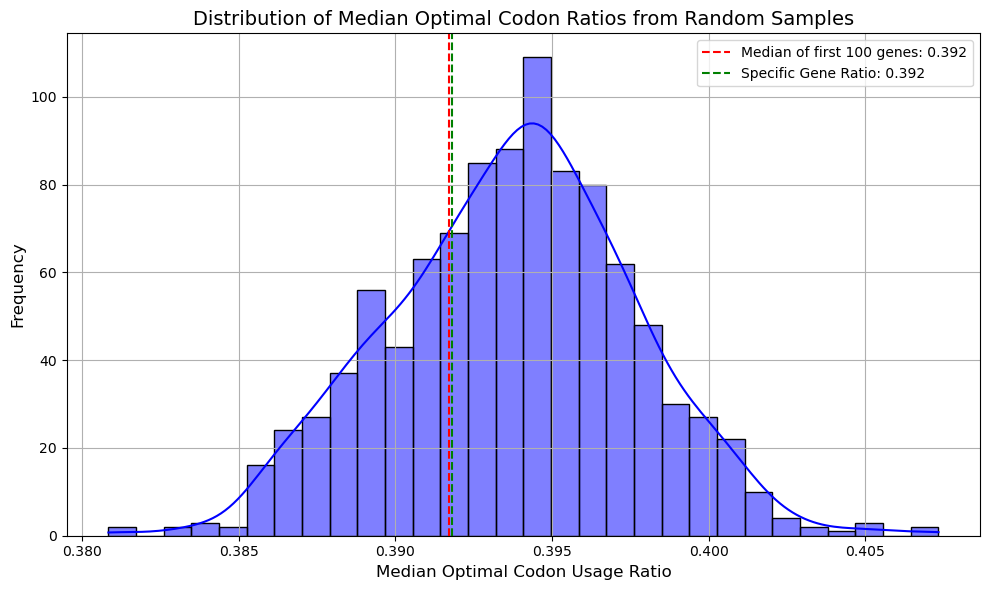

In [ ]:
import random
import statistics
import matplotlib.pyplot as plt
import seaborn as sns



def random_sampling_median(cds_dict, n_samples=100, n_iterations=1000):
    all_medians = []
    
    for _ in range(n_iterations):
        sampled_genes = random.choices(list(cds_dict.values()), k=n_samples)
        optimal_ratios = [ratio_of_optimal_codons(gene) for gene in sampled_genes if len(gene) >= 3]
        median_ratio = statistics.median(optimal_ratios)
        all_medians.append(median_ratio)
    
    return all_medians

def plot_histogram_with_median_line(cds_dict, gene_seqids, specific_gene_sequence =None):
    first_100_genes = [cds_dict[seqid] for seqid in gene_seqids[:100]]
    first_100_ratios = [ratio_of_optimal_codons(gene) for gene in first_100_genes]
    first_100_median = statistics.median(first_100_ratios)
    
    all_medians = random_sampling_median(cds_dict, n_samples=100, n_iterations=1000)
    
    plt.figure(figsize=(10, 6))
    sns.histplot(all_medians, kde=True, bins=30, color='blue')
    
    plt.axvline(x=first_100_median, color='red', linestyle='--', label=f"Median of first 100 genes: {first_100_median:.3f}")
    
    if specific_gene_sequence:
        specific_ratio = ratio_of_optimal_codons(specific_gene_sequence)
        plt.axvline(x=specific_ratio, color='green', linestyle='--', label=f"Specific Gene Ratio: {specific_ratio:.3f}")
    
    plt.title('Distribution of Median Optimal Codon Ratios from Random Samples', fontsize=14)
    plt.xlabel('Median Optimal Codon Usage Ratio', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

key_list = list(elephant_genome_dict.keys())
specific_gene_sequence = elephant_genome_dict[key_list[0]]
plot_histogram_with_median_line(elephant_genome_dict, key_list, specific_gene_sequence=specific_gene_sequence)


- **P-value** is the probability of obtaining test results at least as extreme as the result actually observed if the null hypothesis were true. The **one-sided p-value** is calculated as the proportion of sampled permutations where the median optimal codon ratio (used as the metric here) was lower than the observed. What is the probability that the observed OR optimal codon usage is obtained by chance.

In [44]:
def calculate_one_sided_p_value(cds_dict, gene_seqids):
    first_100_genes = [cds_dict[seqid] for seqid in gene_seqids[:100] if len(cds_dict[seqid]) >= 3]
    first_100_ratios = [ratio_of_optimal_codons(gene) for gene in first_100_genes]
    observed_median = statistics.median(first_100_ratios)

    all_medians = random_sampling_median(cds_dict, n_samples=100, n_iterations=1000)
    p_value = sum(1 for m in all_medians if m <= observed_median) / len(all_medians)

    print(f"Observed Median Optimal Codon Usage: {observed_median:.3f}")
    print(f"One-sided p-value (random median ≤ observed): {p_value:.3f}")

    return p_value
key_list = list(elephant_genome_dict.keys())
specific_gene_sequence = elephant_genome_dict[key_list[0]]
calculate_one_sided_p_value(elephant_genome_dict, key_list)

Observed Median Optimal Codon Usage: 0.392
One-sided p-value (random median ≤ observed): 0.301


0.301

- In the example here we used the ratio of optimal codons over all codons in a gene as a rough proxy of a gene's preference for "optimal" codons or not. Can you think of a more precise way to test this hypothesis, taking into account the number of tRNA genes detected in the elephant genome?